# Model Building — Weekly Demand Forecasting

Pipeline por demand type com cross-validation e Optuna.

| Demand type | Modelo | Estratégia |
|---|---|---|
| Smooth | LightGBM | features + lags + Optuna |
| Erratic | LightGBM | features + lags + Optuna |
| Intermittent | Croston Otimizado | univariado |
| Lumpy | Croston Otimizado | univariado |

**Baseline:** SeasonalNaive (season=52) para todos os tipos.

In [140]:
import warnings
import numpy as np
import pandas as pd
import optuna
from functools import partial

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences, LocalBoxCox, LocalStandardScaler
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from lightgbm import LGBMRegressor

from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, CrostonOptimized

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '../../src')
from config import LoadConfig

cfg = LoadConfig()

In [194]:
# ─── Hiperparâmetros globais ───────────────────────────────────────────────
HORIZON    = 4          # semanas a prever
N_WINDOWS  = 6          # janelas de CV
N_TRIALS   = 50         # trials Optuna por demand type
SEASON_LEN = 52         # sazonalidade anual (semanas)
TARGET_COL = 'y'        # coluna alvo nos refined datasets
SEED       = 42

## 1. Carrega dados

In [195]:
DEMAND_TYPES = ['smooth', 'erratic', 'intermittent', 'lumpy']

# Features estáticas: constantes por unique_id
STATIC_COLS = [
    'product_attribute_1',
    'product_attribute_2',
    'product_attribute_3',
    'supplier_id',
    'region_id',
]

# Features dinâmicas por (ds, region_id) — LightGBM aceita apenas numérico
HOLIDAY_COLS = [
    'is_national_holiday', 'is_holiday',
    'weeks_to_next_holiday', 'weeks_since_last_holiday',
]
WEATHER_COLS = [
    'temp_max',
    'temp_min', 
    'temp_mean',
    'precip', 
    'wind_max',
    #'is_cold', 
    #'is_hot', 
    'is_rainy',
]
DYNAMIC_COLS = HOLIDAY_COLS + WEATHER_COLS   # todas as exógenas dinâmicas

# ── Carrega tabelas de features ───────────────────────────────────────────────
df_features = cfg.load_forecast('features', 'static')
df_static   = df_features[['unique_id'] + STATIC_COLS].drop_duplicates('unique_id')

df_holidays = cfg.load_forecast('features', 'holidays')
df_weather  = cfg.load_forecast('features', 'weather')

# ── Constrói datasets com todas as features mergeadas ────────────────────────
datasets = {}
for dt in DEMAND_TYPES:
    df = cfg.load_forecast('datasets', 'refined', dt)
    df = df.drop(columns=['demand_type'], errors='ignore')
    df = df.merge(df_static, on='unique_id', how='left')
    df = df.merge(df_holidays[['ds', 'region_id'] + HOLIDAY_COLS],
                  on=['ds', 'region_id'], how='left')
    df = df.merge(df_weather[['ds', 'region_id'] + WEATHER_COLS],
                  on=['ds', 'region_id'], how='left')
    datasets[dt] = df

# Detecta o dia-âncora real das séries (ex: 'W-MON')
_day_abbrevs = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN']
_day_num = datasets['smooth']['ds'].dt.dayofweek.mode()[0]
FREQ = f'W-{_day_abbrevs[_day_num]}'

for dt, df in datasets.items():
    print(f'{dt:<15}: {df["unique_id"].nunique():>5,} séries | {df.shape[1]:>2} colunas '
          f'| NaN weather: {df[WEATHER_COLS].isna().any(axis=1).mean():.1%}')
print(f'\nFrequência  : {FREQ}')
print(f'Holiday cols: {HOLIDAY_COLS}')
print(f'Weather cols: {WEATHER_COLS}')

smooth         :   542 séries | 18 colunas | NaN weather: 0.0%
erratic        :   433 séries | 18 colunas | NaN weather: 0.0%
intermittent   :   700 séries | 18 colunas | NaN weather: 0.0%
lumpy          :   557 séries | 18 colunas | NaN weather: 0.0%

Frequência  : W-MON
Holiday cols: ['is_national_holiday', 'is_holiday', 'weeks_to_next_holiday', 'weeks_since_last_holiday']
Weather cols: ['temp_max', 'temp_min', 'temp_mean', 'precip', 'wind_max', 'is_rainy']


## 2. Train / Test split (time-based)

In [196]:
def train_test_split(df: pd.DataFrame, horizon: int):
    """Corta as últimas `horizon` semanas como test. Sem data leakage."""
    cutoff = df['ds'].max() - pd.Timedelta(weeks=horizon)
    train  = df[df['ds'] <= cutoff].copy()
    test   = df[df['ds'] >  cutoff].copy()
    return train, test


splits = {dt: train_test_split(datasets[dt], HORIZON) for dt in DEMAND_TYPES}

print(f'Cutoff: {splits["smooth"][0]["ds"].max().date()}')
for dt, (train, test) in splits.items():
    print(f'{dt:<15}: train={len(train):>7,}  test={len(test):>6,}')

Cutoff: 2024-09-23
smooth         : train= 46,352  test= 2,084
erratic        : train= 36,188  test= 1,579
intermittent   : train= 50,664  test= 1,156
lumpy          : train= 46,659  test= 1,370


## 3. Stats leakage-free (computadas só no treino)

In [197]:
def add_train_stats(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """cv, iqr, q50 computados apenas no treino — aplicados em treino e test."""
    stats = (
        df_train.groupby('unique_id')[TARGET_COL]
        .agg(
            cv   = lambda x: x.std() / x.mean() if x.mean() > 0 else 0,
            q50  = lambda x: x.quantile(0.5),
            iqr  = lambda x: x.quantile(0.75) - x.quantile(0.25),
        )
        .reset_index()
    )
    return (
        df_train.merge(stats, on='unique_id'),
        df_test.merge(stats, on='unique_id')
    )


#for dt in DEMAND_TYPES:
#    splits[dt] = add_train_stats(*splits[dt])

#print('Stats adicionadas (treino-only):', ['cv', 'q50', 'iqr'])

## 4. Métricas

In [198]:
def mase(y_true: np.ndarray, y_pred: np.ndarray, y_train: np.ndarray) -> float:
    """Mean Absolute Scaled Error. Robusto para séries esparsas (sem divisão por zero)."""
    naive_mae = np.mean(np.abs(np.diff(y_train)))
    if naive_mae == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / naive_mae


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Symmetric MAPE — estável quando y_true=0."""
    denom = np.abs(y_true) + np.abs(y_pred)
    mask  = denom > 0
    return 2 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Weighted APE — melhor que MAPE para séries com zeros."""
    total = np.sum(np.abs(y_true))
    if total == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / total


def evaluate_forecast(df_pred: pd.DataFrame, df_train: pd.DataFrame,
                       model_col: str) -> dict:
    """Avalia um modelo coluna por série e retorna métricas agregadas."""
    results = []
    for uid, group in df_pred.groupby('unique_id'):
        y_true  = group[TARGET_COL].to_numpy(dtype=float)
        y_hat   = group[model_col].to_numpy(dtype=float)
        y_train = df_train[df_train['unique_id'] == uid][TARGET_COL].to_numpy(dtype=float)
        results.append({
            'unique_id': uid,
            'mase':  mase(y_true, y_hat, y_train),
            'smape': smape(y_true, y_hat),
            'wape':  wape(y_true, y_hat),
        })
    df_res = pd.DataFrame(results)
    return {
        'mase':  df_res['mase'].mean(),
        'smape': df_res['smape'].mean(),
        'wape':  df_res['wape'].mean(),
        'n_series': len(df_res),
    }

## 5. Baseline — SeasonalNaive & Croston

In [70]:
def run_baseline(df_train: pd.DataFrame, df_test: pd.DataFrame,
                 demand_type: str, horizon: int) -> pd.DataFrame:
    """
    SeasonalNaive para smooth/erratic.
    CrostonOptimized para intermittent/lumpy.
    """
    if demand_type in ('smooth', 'erratic'):
        models = [SeasonalNaive(season_length=SEASON_LEN)]
    else:
        models = [CrostonOptimized()]

    sf = StatsForecast(models=models, freq=FREQ, n_jobs=-1)
    sf.fit(df_train[['unique_id', 'ds', TARGET_COL]])
    preds = sf.predict(h=horizon)

    # Alinha por posição (rank dentro de cada série) em vez de datas
    test_ranked = (
        df_test[['unique_id', 'ds', TARGET_COL]]
        .sort_values(['unique_id', 'ds'])
        .assign(rank=lambda d: d.groupby('unique_id').cumcount())
    )
    preds_ranked = (
        preds
        .sort_values(['unique_id', 'ds'])
        .assign(rank=lambda d: d.groupby('unique_id').cumcount())
        .drop(columns='ds')
    )

    return test_ranked.merge(preds_ranked, on=['unique_id', 'rank'], how='left').drop(columns='rank')


baseline_results = {}
baseline_preds   = {}

for dt in DEMAND_TYPES:
    train, test = splits[dt]
    preds = run_baseline(train, test, dt, HORIZON)
    model_col = 'SeasonalNaive' if dt in ('smooth', 'erratic') else 'CrostonOptimized'
    baseline_results[dt] = evaluate_forecast(preds, train, model_col)
    baseline_preds[dt]   = preds
    print(f'{dt:<15}: MASE={baseline_results[dt]["mase"]:.4f}  '
          f'SMAPE={baseline_results[dt]["smape"]:.4f}  '
          f'WAPE={baseline_results[dt]["wape"]:.4f}')

smooth         : MASE=1.0492  SMAPE=0.7192  WAPE=0.8209
erratic        : MASE=1.3153  SMAPE=1.0487  WAPE=2.3754
intermittent   : MASE=1.6952  SMAPE=1.1257  WAPE=1.2579
lumpy          : MASE=1.1788  SMAPE=0.9631  WAPE=1.1997


## 6. Optuna — LightGBM (Smooth & Erratic)

**Search space:**
- `lag_preset` : short=[4,13] / medium=[4,8,13,26] / long=[4,8,13,26,52]
- `lag_transform` : expanding_mean / rolling_mean_4 / rolling_mean_13 / none
- `target_transform` : none / log1p (BoxCox) / detrend (Differences) / normalize
- Hiperparâmetros LightGBM: learning_rate, num_leaves, n_estimators, lambda_l1/l2, feature_fraction, bagging_fraction

In [199]:
LAG_PRESETS = {
    'short':  [4, 13],
    'medium': [4, 8, 13, 26],
    'long':   [4, 8, 13, 26, 52],
}

LAG_TRANSFORM_MAP = {
    #'expanding_mean':  ExpandingMean(),
    'rolling_mean_4':  RollingMean(window_size=4),
    'rolling_mean_13': RollingMean(window_size=13),
    'none':            None,
}

TARGET_TRANSFORM_MAP = {
    'none':      [],
    'log1p':     [LocalBoxCox()],
    'detrend':   [Differences([1])],
    'normalize': [LocalStandardScaler()],
}

# Estáticas: constantes por série (product attrs + entity ids + stats do treino)
STATIC_FEATURES = STATIC_COLS + ['cv', 'q50', 'iqr']


def build_mlforecast(trial, df_train: pd.DataFrame) -> tuple:
    """Constrói MLForecast com configuração sugerida pelo trial."""

    lag_preset = trial.suggest_categorical('lag_preset', list(LAG_PRESETS.keys()))
    lags = LAG_PRESETS[lag_preset]

    lag_tf_name = trial.suggest_categorical('lag_transform', list(LAG_TRANSFORM_MAP.keys()))
    lag_tf      = LAG_TRANSFORM_MAP[lag_tf_name]
    lag_transforms = {lag: [lag_tf] for lag in lags} if lag_tf is not None else None

    target_tf_name    = trial.suggest_categorical('target_transform', list(TARGET_TRANSFORM_MAP.keys()))
    target_transforms = TARGET_TRANSFORM_MAP[target_tf_name] or None

    model_params = {
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 31, 512),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'lambda_l1':        trial.suggest_float('lambda_l1', 0.01, 10.0, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 0.01, 10.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq':     1,
        'random_state':     SEED,
        'verbose':         -1,
    }
    

    available_static = [c for c in STATIC_FEATURES if c in df_train.columns]

    mlf = MLForecast(
        models=[LGBMRegressor(**model_params)],
        freq=FREQ,                                       # usa freq detectada dos dados
        lags=lags,
        lag_transforms=lag_transforms,
        target_transforms=target_transforms,
        date_features=['month', 'quarter', 'week'],
    )
    return mlf, available_static


def cv_loss(mlf: MLForecast, df_train: pd.DataFrame,
            static_features: list, horizon: int, n_windows: int) -> float:
    """Roda CV e retorna MASE médio."""
    cv_df = mlf.cross_validation(
        df_train,
        h=horizon,
        n_windows=n_windows,
        step_size=1,
        static_features=static_features,
        fitted=False,
    )

    scores = []
    for uid, group in cv_df.groupby('unique_id'):
        y_true   = group[TARGET_COL].to_numpy(dtype=float)
        y_hat    = group['LGBMRegressor'].to_numpy(dtype=float)
        y_train_ = df_train[df_train['unique_id'] == uid][TARGET_COL].to_numpy(dtype=float)
        s = mase(y_true, y_hat, y_train_)
        if not np.isnan(s):
            scores.append(s)

    return np.mean(scores) if scores else np.inf


def run_optuna(df_train: pd.DataFrame, demand_type: str,
               n_trials: int = N_TRIALS) -> optuna.Study:

    def objective(trial):
        mlf, static_features = build_mlforecast(trial, df_train)
        return cv_loss(mlf, df_train, static_features, HORIZON, N_WINDOWS)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
        study_name=f'lgbm_{demand_type}',
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    sep = '=' * 50
    print(f'\n{demand_type} — melhor MASE (CV): {study.best_value:.4f}')
    print(f'  Params: {study.best_params}')
    return study

In [200]:
# Roda Optuna para Smooth e Erratic
ML_TYPES = ['smooth']

studies = {}
for dt in ML_TYPES:
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'Otimizando: {dt.upper()}')
    print(sep)
    train, _ = splits[dt]
    studies[dt] = run_optuna(train, dt)


Otimizando: SMOOTH


  0%|          | 0/50 [00:00<?, ?it/s]


smooth — melhor MASE (CV): 0.6608
  Params: {'lag_preset': 'long', 'lag_transform': 'none', 'target_transform': 'normalize', 'learning_rate': 0.023715651950861578, 'num_leaves': 243, 'n_estimators': 155, 'lambda_l1': 0.019094703002940222, 'lambda_l2': 0.014359344412799445, 'feature_fraction': 0.9910960990172188, 'bagging_fraction': 0.6260695732046843}


## 7. Treino final com melhores params + predição no test

In [201]:
def train_and_predict(df_train: pd.DataFrame, df_test: pd.DataFrame,
                       best_params: dict) -> pd.DataFrame:
    """Treina com os melhores params e prediz no test set."""

    class _FakeTrial:
        def suggest_categorical(self, name, choices): return best_params[name]
        def suggest_int(self, name, *a, **k):         return best_params[name]
        def suggest_float(self, name, *a, **k):       return best_params[name]

    mlf, static_features = build_mlforecast(_FakeTrial(), df_train)
    mlf.fit(df_train, static_features=static_features)

    # Colunas dinâmicas presentes no treino
    avail_dynamic = [c for c in DYNAMIC_COLS if c in df_train.columns]

    if avail_dynamic:
        # Grid exato de datas futuras esperado pelo MLForecast
        future = (
            mlf.make_future_dataframe(h=HORIZON)
            .merge(df_static[['unique_id', 'region_id']], on='unique_id', how='left')
        )
        # Merge holidays
        avail_hol = [c for c in HOLIDAY_COLS if c in avail_dynamic]
        if avail_hol:
            future = future.merge(
                df_holidays[['ds', 'region_id'] + avail_hol],
                on=['ds', 'region_id'], how='left'
            )
        # Merge weather (lag 52w já aplicado no parquet — sem leakage)
        avail_wth = [c for c in WEATHER_COLS if c in avail_dynamic]
        if avail_wth:
            future = future.merge(
                df_weather[['ds', 'region_id'] + avail_wth],
                on=['ds', 'region_id'], how='left'
            )
        # region_id já entra como static feature — remove do X_df
        future_exog = future.drop(columns='region_id')
        preds = mlf.predict(h=HORIZON, X_df=future_exog)
    else:
        preds = mlf.predict(h=HORIZON)

    return df_test[['unique_id', 'ds', TARGET_COL]].merge(
        preds, on=['unique_id', 'ds'], how='left'
    )


ml_results = {}
ml_preds   = {}

for dt in ML_TYPES:
    train, test = splits[dt]
    preds = train_and_predict(train, test, studies[dt].best_params)
    ml_results[dt] = evaluate_forecast(preds, train, 'LGBMRegressor')
    ml_preds[dt]   = preds
    print(f'{dt:<15}: MASE={ml_results[dt]["mase"]:.4f}  '
          f'SMAPE={ml_results[dt]["smape"]:.4f}  '
          f'WAPE={ml_results[dt]["wape"]:.4f}')

smooth         : MASE=0.7618  SMAPE=0.4992  WAPE=0.6342


## 8. Resultados — Baseline vs ML

In [202]:
rows = []
for dt in DEMAND_TYPES:
    b = baseline_results[dt]
    rows.append({'demand_type': dt, 'model': 'Baseline',
                 'mase': b['mase'], 'smape': b['smape'], 'wape': b['wape']})
    if dt in ml_results:
        m = ml_results[dt]
        rows.append({'demand_type': dt, 'model': 'LightGBM',
                     'mase': m['mase'], 'smape': m['smape'], 'wape': m['wape']})

df_summary = pd.DataFrame(rows).set_index(['demand_type', 'model']).round(4)

sep = '=' * 60
print(f'\n{sep}')
print('RESULTADOS — BASELINE vs LIGHTGBM')
print(sep)
print(df_summary.to_string())

# Melhoria relativa
print('\nMelhoria LightGBM vs Baseline (MASE):')
for dt in ML_TYPES:
    base = baseline_results[dt]['mase']
    ml   = ml_results[dt]['mase']
    delta = (base - ml) / base * 100
    sign  = '+' if delta > 0 else ''
    print(f'  {dt:<15}: {sign}{delta:.1f}%  ({base:.4f} -> {ml:.4f})')


RESULTADOS — BASELINE vs LIGHTGBM
                         mase   smape    wape
demand_type  model                           
smooth       Baseline  1.0492  0.7192  0.8209
             LightGBM  0.7618  0.4992  0.6342
erratic      Baseline  1.3153  1.0487  2.3754
intermittent Baseline  1.6952  1.1257  1.2579
lumpy        Baseline  1.1788  0.9631  1.1997

Melhoria LightGBM vs Baseline (MASE):
  smooth         : +27.4%  (1.0492 -> 0.7618)


## 9. Seleção de Modelos Estatísticos — Erratic / Intermittent / Lumpy

O LightGBM global não bateu o baseline nesses tipos. Estratégia: testar candidatos estatísticos via CV e reter o vencedor por demand type.

| Tipo | Problema | Candidatos |
|---|---|---|
| Erratic | Timing regular, tamanho altamente variável | AutoETS, AutoTheta, SES sazonal |
| Intermittent | Demanda esparsa, tamanho constante | TSB, ADIDA, IMAPA, CrostonSBA |
| Lumpy | Esparso + alta variância — pior caso | IMAPA, TSB, CrostonSBA |

**Métrica de seleção:** WAPE médio em CV (mais estável que MASE para séries com zeros).

In [103]:
from statsforecast.models import (
    AutoETS, AutoTheta,
    SeasonalExponentialSmoothing,
    TSB, ADIDA, IMAPA, CrostonSBA,
)

STATS_CANDIDATES = {
    'erratic': [
        AutoETS(season_length=SEASON_LEN),
        AutoTheta(season_length=SEASON_LEN),
        SeasonalExponentialSmoothing(season_length=SEASON_LEN, alpha=0.3),
        CrostonOptimized(),
    ],
    'intermittent': [
        TSB(alpha_d=0.3, alpha_p=0.3),
        ADIDA(),
        IMAPA(),
        CrostonSBA(),
        CrostonOptimized(),
    ],
    'lumpy': [
        IMAPA(),
        TSB(alpha_d=0.3, alpha_p=0.3),
        CrostonSBA(),
        CrostonOptimized(),
    ],
}

STATS_TYPES = ['erratic', 'intermittent', 'lumpy']


def _model_col(cv_df: pd.DataFrame) -> str:
    skip = {'unique_id', 'ds', 'cutoff', TARGET_COL}
    return next(c for c in cv_df.columns if c not in skip)


def _filter_min_length(df_train: pd.DataFrame, horizon: int,
                       n_windows: int, season_len: int = 0) -> pd.DataFrame:
    """Remove séries curtas demais para o CV. Modelos sazonais precisam de 2× season."""
    min_obs = horizon * (n_windows + 1) + max(season_len, 0)
    counts  = df_train.groupby('unique_id').size()
    valid   = counts[counts >= min_obs].index
    dropped = len(counts) - len(valid)
    if dropped:
        print(f'    (descartadas {dropped} séries curtas — min_obs={min_obs})')
    return df_train[df_train['unique_id'].isin(valid)]


def select_best_stats(candidates: list, df_train: pd.DataFrame,
                      horizon: int, n_windows: int) -> tuple:
    """
    Avalia cada candidato via CV com step_size=horizon (janelas não-sobrepostas).
    Séries curtas demais são removidas antes do CV de cada modelo.
    Fallback para CrostonOptimized se todos falharem.
    """
    results = {}
    for model in candidates:
        name = type(model).__name__
        # Modelos sazonais precisam de mais histórico
        season = getattr(model, 'season_length', 0) or 0
        df_cv  = _filter_min_length(df_train, horizon, n_windows, season_len=season)

        if df_cv['unique_id'].nunique() == 0:
            print(f'  {name:<45}: sem séries suficientes, pulado')
            continue
        try:
            sf    = StatsForecast(models=[model], freq=FREQ, n_jobs=-1)
            cv_df = sf.cross_validation(
                df=df_cv[['unique_id', 'ds', TARGET_COL]],
                h=horizon,
                n_windows=n_windows,
                step_size=horizon,
            )
            col    = _model_col(cv_df)
            scores = [
                wape(g[TARGET_COL].to_numpy(dtype=float),
                     g[col].to_numpy(dtype=float))
                for _, g in cv_df.groupby('unique_id')
            ]
            mean_w = float(np.nanmean(scores)) if scores else np.inf
            results[col] = (model, mean_w)
            n_series = df_cv['unique_id'].nunique()
            print(f'  {col:<45}: CV WAPE = {mean_w:.4f}  ({n_series} séries)')
        except Exception as e:
            print(f'  {name:<45}: ERRO — {e}')

    if not results:
        # Fallback: usa CrostonOptimized sem CV
        print('  Nenhum modelo completou CV — usando CrostonOptimized como fallback')
        return CrostonOptimized(), 'CrostonOptimized', np.inf

    best_col        = min(results, key=lambda k: results[k][1])
    best_mdl, best_w = results[best_col]
    print(f'\n  Vencedor: {best_col}  (CV WAPE = {best_w:.4f})')
    return best_mdl, best_col, best_w


# ── Executa seleção por demand type ──────────────────────────────────────────
stats_winners = {}

for dt in STATS_TYPES:
    sep = '=' * 60
    print(f'\n{sep}\nSelecionando: {dt.upper()}\n{sep}')
    train, _ = splits[dt]
    m, col, w = select_best_stats(STATS_CANDIDATES[dt], train, HORIZON, N_WINDOWS)
    stats_winners[dt] = {'model': m, 'col': col, 'cv_wape': w}


Selecionando: ERRATIC
    (descartadas 114 séries curtas — min_obs=80)
  AutoETS                                      : CV WAPE = 0.9473  (319 séries)
    (descartadas 114 séries curtas — min_obs=80)
  AutoTheta                                    : CV WAPE = 0.9159  (319 séries)
    (descartadas 114 séries curtas — min_obs=80)
  SeasonalES                                   : CV WAPE = 2.1252  (319 séries)
    (descartadas 35 séries curtas — min_obs=28)
  CrostonOptimized                             : CV WAPE = 0.8742  (398 séries)

  Vencedor: CrostonOptimized  (CV WAPE = 0.8742)

Selecionando: INTERMITTENT
    (descartadas 91 séries curtas — min_obs=28)
  TSB                                          : CV WAPE = 1.5151  (607 séries)
    (descartadas 91 séries curtas — min_obs=28)
  ADIDA                                        : CV WAPE = 1.6081  (607 séries)
    (descartadas 91 séries curtas — min_obs=28)
  IMAPA                                        : CV WAPE = 1.5886  (607 séries)


In [122]:
def run_stats_model(model, model_col: str,
                    df_train: pd.DataFrame, df_test: pd.DataFrame,
                    horizon: int) -> pd.DataFrame:
    """Treina e prediz com um modelo StatsForecast. Alinha por rank para evitar offset de datas."""
    sf = StatsForecast(models=[model], freq=FREQ, n_jobs=-1)
    sf.fit(df_train[['unique_id', 'ds', TARGET_COL]])
    preds = sf.predict(h=horizon)

    test_r = (df_test[['unique_id', 'ds', TARGET_COL]]
              .sort_values(['unique_id', 'ds'])
              .assign(rank=lambda d: d.groupby('unique_id').cumcount()))
    pred_r = (preds.sort_values(['unique_id', 'ds'])
              .assign(rank=lambda d: d.groupby('unique_id').cumcount())
              .drop(columns='ds'))
    return test_r.merge(pred_r, on=['unique_id', 'rank'], how='left').drop(columns='rank')


# ── Avaliação final no test set ───────────────────────────────────────────────
stats_results = {}
stats_preds   = {}

for dt in STATS_TYPES:
    train, test = splits[dt]
    w            = stats_winners[dt]
    preds        = run_stats_model(w['model'], w['col'], train, test, HORIZON)
    stats_results[dt] = evaluate_forecast(preds, train, w['col'])
    stats_preds[dt]   = preds

# ── Tabela comparativa completa ───────────────────────────────────────────────
rows = []
for dt in DEMAND_TYPES:
    rows.append({'demand_type': dt, 'model': 'Baseline (CrostonOpt/SeasonalNaive)',
                 **{k: baseline_results[dt][k] for k in ['mase','smape','wape']}})
    if dt in ml_results:
        rows.append({'demand_type': dt, 'model': 'LightGBM (global)',
                     **{k: ml_results[dt][k] for k in ['mase','smape','wape']}})
    if dt in stats_results:
        col  = stats_winners[dt]['col']
        rows.append({'demand_type': dt, 'model': f'Stats ({col})',
                     **{k: stats_results[dt][k] for k in ['mase','smape','wape']}})

df_final = pd.DataFrame(rows).set_index(['demand_type', 'model']).round(4)

sep = '=' * 70
print(f'\n{sep}')
print('COMPARACAO FINAL — Baseline  vs  LightGBM  vs  Melhor Estatístico')
print(sep)
print(df_final.to_string())

print('\nDelta WAPE — Melhor Estatístico vs Baseline:')
for dt in STATS_TYPES:
    base_w  = baseline_results[dt]['wape']
    stats_w = stats_results[dt]['wape']
    delta   = (base_w - stats_w) / base_w * 100
    sign    = '+' if delta > 0 else ''
    print(f'  {dt:<15}: {sign}{delta:.1f}%  ({base_w:.4f} -> {stats_w:.4f})')


COMPARACAO FINAL — Baseline  vs  LightGBM  vs  Melhor Estatístico
                                                    mase   smape    wape
demand_type  model                                                      
smooth       Baseline (CrostonOpt/SeasonalNaive)  1.0492  0.7192  0.8209
             LightGBM (global)                    0.6671  0.4548  0.4857
erratic      Baseline (CrostonOpt/SeasonalNaive)  1.3153  1.0487  2.3754
             Stats (CrostonOptimized)             1.2502  0.7017  1.0437
intermittent Baseline (CrostonOpt/SeasonalNaive)  1.6952  1.1257  1.2579
             Stats (TSB)                          1.7272  1.3007  0.8827
lumpy        Baseline (CrostonOpt/SeasonalNaive)  1.1788  0.9631  1.1997
             Stats (TSB)                          1.1742  1.0928  0.9698

Delta WAPE — Melhor Estatístico vs Baseline:
  erratic        : +56.1%  (2.3754 -> 1.0437)
  intermittent   : +29.8%  (1.2579 -> 0.8827)
  lumpy          : +19.2%  (1.1997 -> 0.9698)


## 10. Visualização das Previsões — Seleção por WAPE

2 séries com **WAPE bom**, 1 **razoável** (mediana), 2 com **WAPE ruim**.

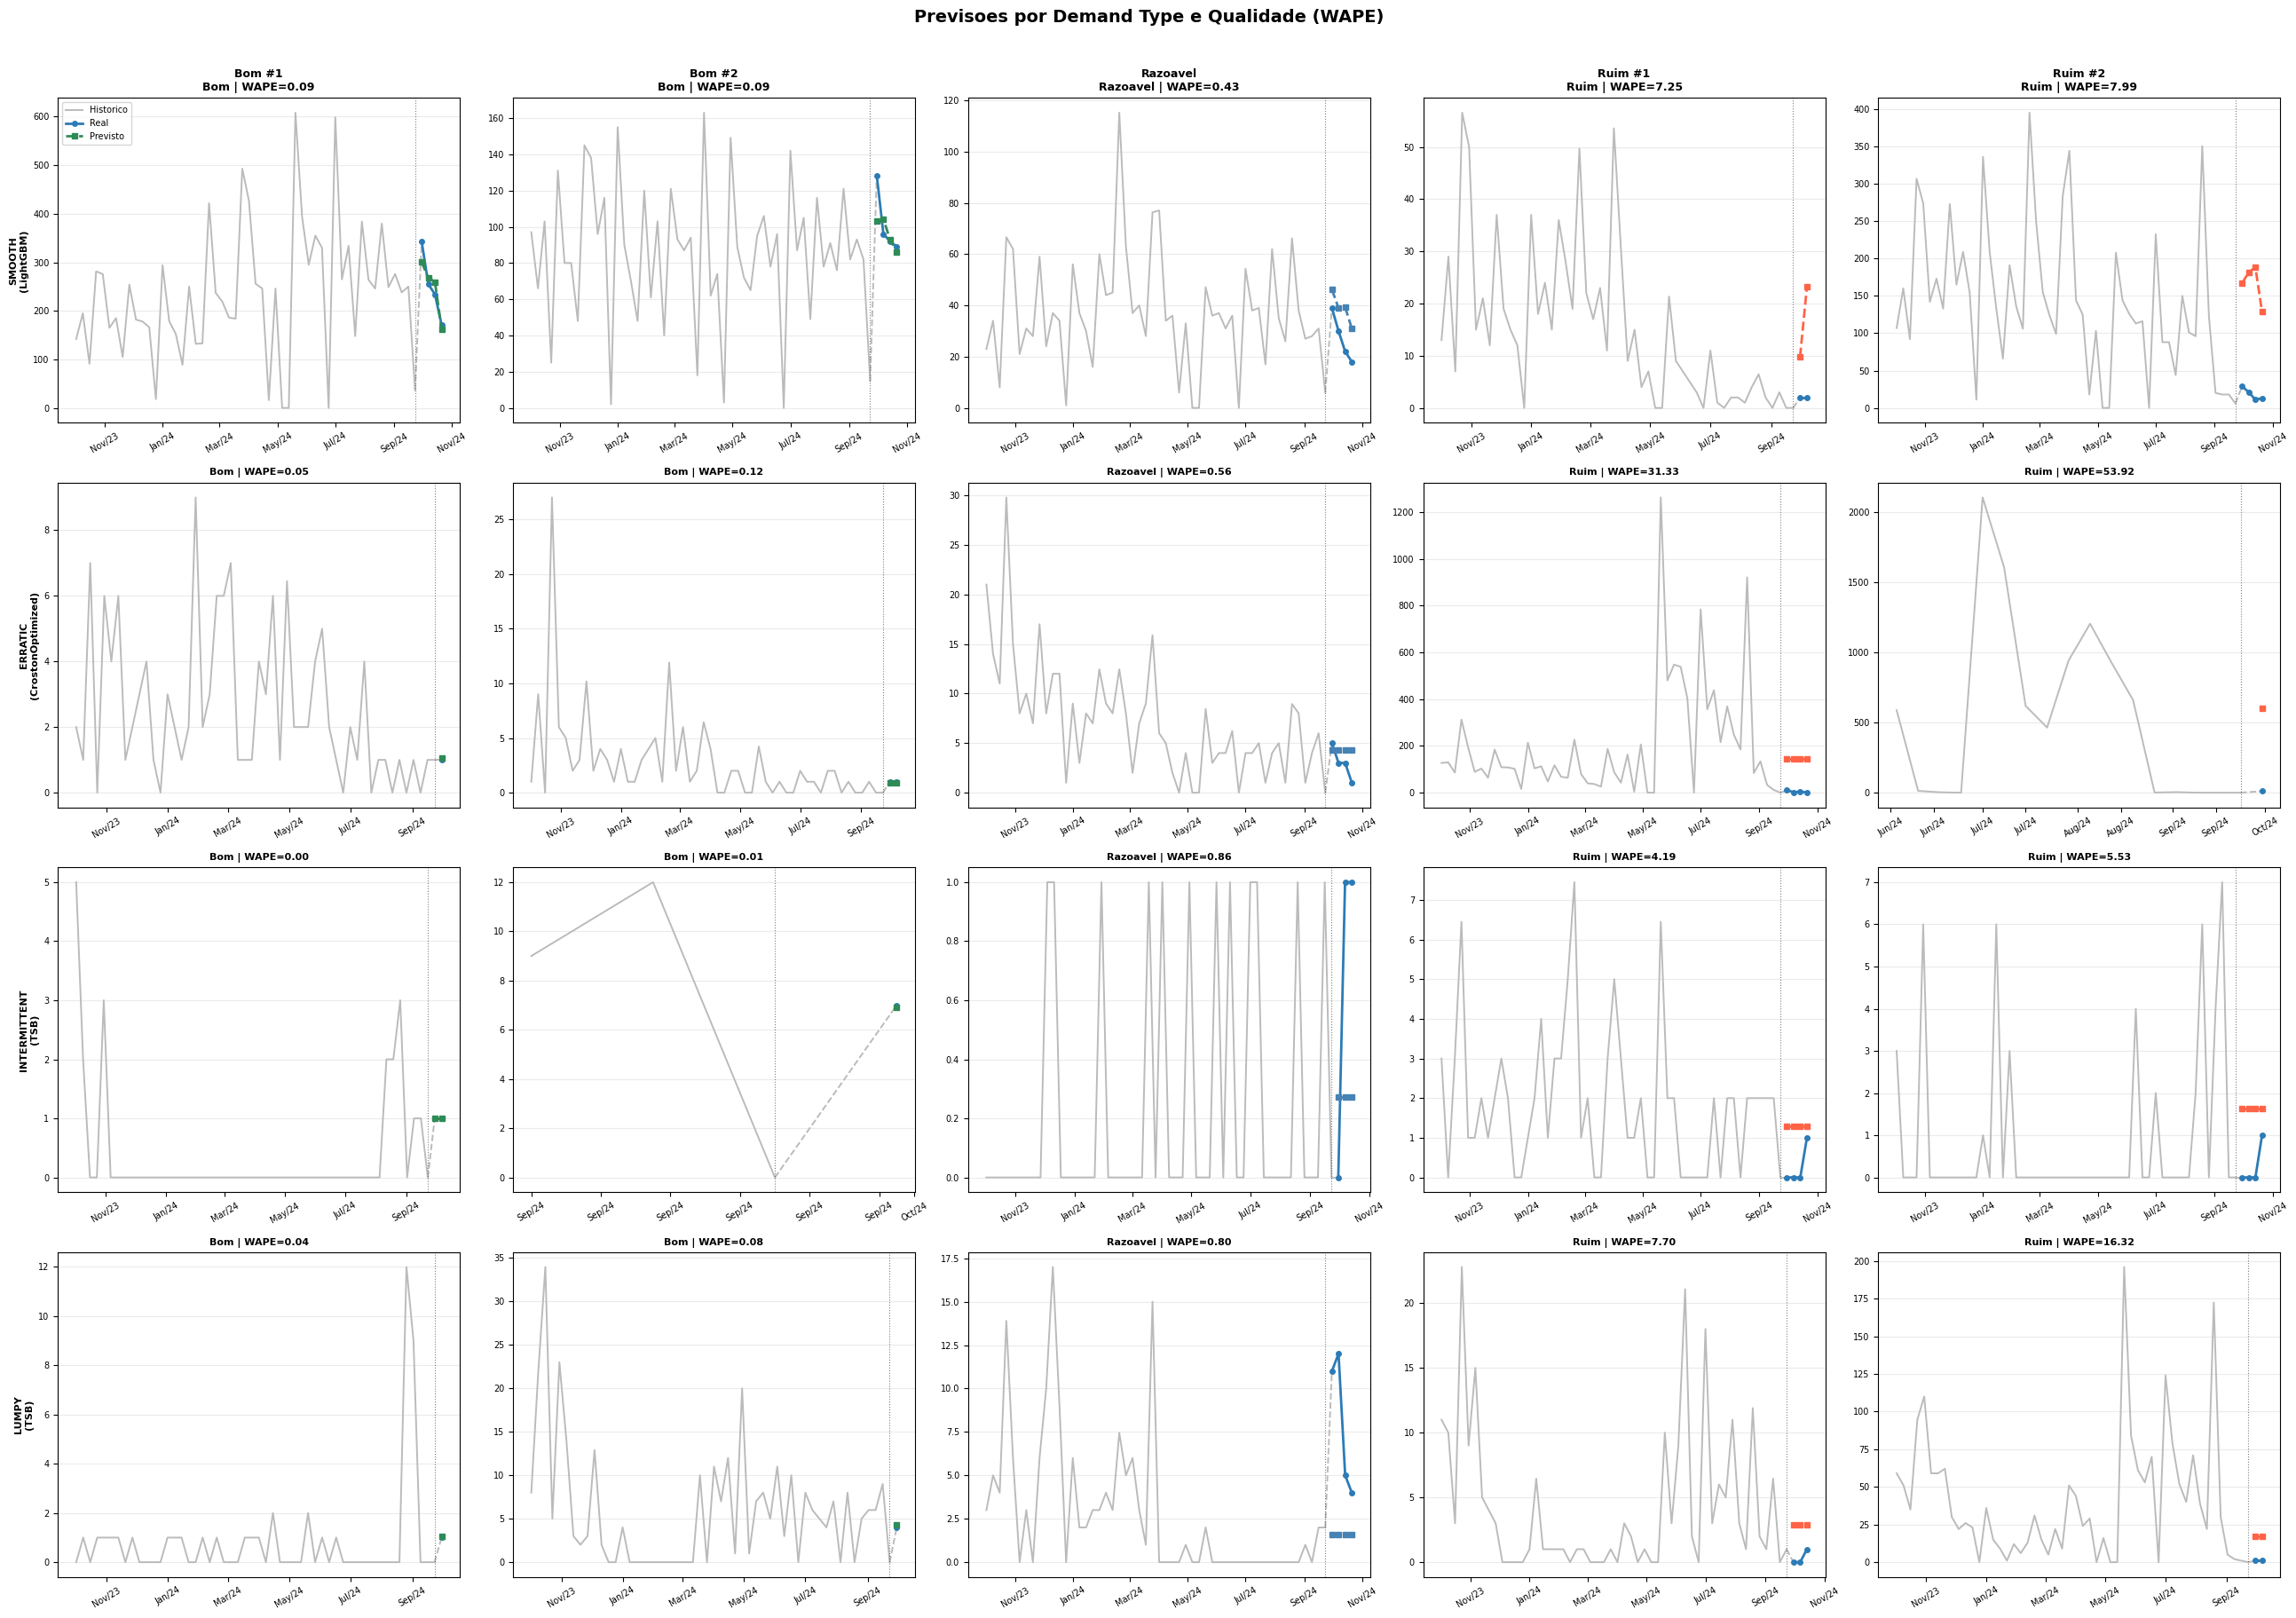


Distribuicao WAPE por demand type:
  smooth          (LightGBM                      ): p10=0.09  p50=0.43  p90=7.70
  erratic         (CrostonOptimized              ): p10=0.08  p50=0.56  p90=44.89
  intermittent    (TSB                           ): p10=0.00  p50=0.86  p90=4.99
  lumpy           (TSB                           ): p10=0.06  p50=0.80  p90=12.87


In [203]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

os.makedirs('../../plots', exist_ok=True)

N_HIST = 52   # semanas de histórico antes do cutoff

# ── Mapa de previsões e colunas por demand type ──────────────────────────────
all_preds = {
    'smooth':       (ml_preds['smooth'],       'LGBMRegressor',                'LightGBM'),
    'erratic':      (stats_preds['erratic'],    stats_winners['erratic']['col'],      stats_winners['erratic']['col']),
    'intermittent': (stats_preds['intermittent'], stats_winners['intermittent']['col'], stats_winners['intermittent']['col']),
    'lumpy':        (stats_preds['lumpy'],      stats_winners['lumpy']['col'],        stats_winners['lumpy']['col']),
}

QUALITY_ORDER = [
    ('Bom',      'seagreen',   slice(None, 2)),
    ('Razoavel', 'steelblue',  None),              # mediana
    ('Ruim',     'tomato',     slice(-2, None)),
]

# ── 1. WAPE por série, por demand type ───────────────────────────────────────
wape_by_type = {}
for dt, (preds_df, col, _) in all_preds.items():
    train_df, _ = splits[dt]
    rows = []
    for uid, grp in preds_df.groupby('unique_id'):
        y_true = grp[TARGET_COL].to_numpy(dtype=float)
        y_hat  = grp[col].to_numpy(dtype=float)
        w = wape(y_true, y_hat)
        if not np.isnan(w):
            rows.append({'unique_id': uid, 'wape': w})
    df_w = pd.DataFrame(rows).sort_values('wape').reset_index(drop=True)
    n = len(df_w)
    selected = pd.concat([
        df_w.head(2).assign(quality='Bom',      color='seagreen'),
        df_w.iloc[[n // 2]].assign(quality='Razoavel', color='steelblue'),
        df_w.tail(2).assign(quality='Ruim',     color='tomato'),
    ], ignore_index=True)
    wape_by_type[dt] = selected

# ── 2. Grade 4 linhas × 5 colunas ────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(26, 18))

for row_idx, dt in enumerate(DEMAND_TYPES):
    preds_df, col, model_label = all_preds[dt]
    train_df, test_df = splits[dt]
    selected = wape_by_type[dt]

    for col_idx, (_, row) in enumerate(selected.iterrows()):
        ax  = axes[row_idx, col_idx]
        uid = row['unique_id']
        w   = row['wape']
        q   = row['quality']
        c   = row['color']

        hist   = train_df[train_df['unique_id'] == uid].sort_values('ds').tail(N_HIST)
        actual = test_df[test_df['unique_id'] == uid].sort_values('ds')
        pred   = preds_df[preds_df['unique_id'] == uid].sort_values('ds')

        cutoff = hist['ds'].max()

        # Histórico
        ax.plot(hist['ds'], hist[TARGET_COL],
                color='#bbbbbb', linewidth=1.4, label='Historico')
        # Bridge histórico → test
        ax.plot([cutoff, actual['ds'].iloc[0]],
                [hist[TARGET_COL].iloc[-1], actual[TARGET_COL].iloc[0]],
                color='#bbbbbb', linewidth=1.4, linestyle='--')
        # Real
        ax.plot(actual['ds'], actual[TARGET_COL],
                color='#2c7bb6', linewidth=2, marker='o', markersize=4, label='Real')
        # Previsto
        ax.plot(pred['ds'], pred[col],
                color=c, linewidth=2, marker='s', markersize=4,
                linestyle='--', label='Previsto')
        # Linha de corte
        ax.axvline(cutoff, color='black', linestyle=':', linewidth=0.8, alpha=0.5)

        ax.set_title(f'{q} | WAPE={w:.2f}', fontsize=8, fontweight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.25)

        # Rótulo da linha (demand type + modelo) apenas na primeira coluna
        if col_idx == 0:
            ax.set_ylabel(f'{dt.upper()}\n({model_label})', fontsize=8, fontweight='bold')

        # Legenda apenas no primeiro subplot de cada linha
        if col_idx == 0 and row_idx == 0:
            ax.legend(fontsize=7, loc='upper left')

# Cabeçalhos das colunas
col_titles = ['Bom #1', 'Bom #2', 'Razoavel', 'Ruim #1', 'Ruim #2']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(f'{title}\n{axes[0, j].get_title()}',
                         fontsize=9, fontweight='bold')

fig.suptitle('Previsoes por Demand Type e Qualidade (WAPE)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../plots/forecast_samples_all_types.png', dpi=130, bbox_inches='tight')
plt.show()

# ── 3. Resumo WAPE por tipo ───────────────────────────────────────────────────
print('\nDistribuicao WAPE por demand type:')
for dt in DEMAND_TYPES:
    df_w = wape_by_type[dt]
    all_w = pd.concat([
        wape_by_type[dt][['unique_id','wape']],
    ])
    _, col, label = all_preds[dt]
    print(f'  {dt:<15} ({label:<30}): '
          f'p10={df_w["wape"].quantile(0.1):.2f}  '
          f'p50={df_w["wape"].quantile(0.5):.2f}  '
          f'p90={df_w["wape"].quantile(0.9):.2f}')

## 11. SHAP — Feature Importance

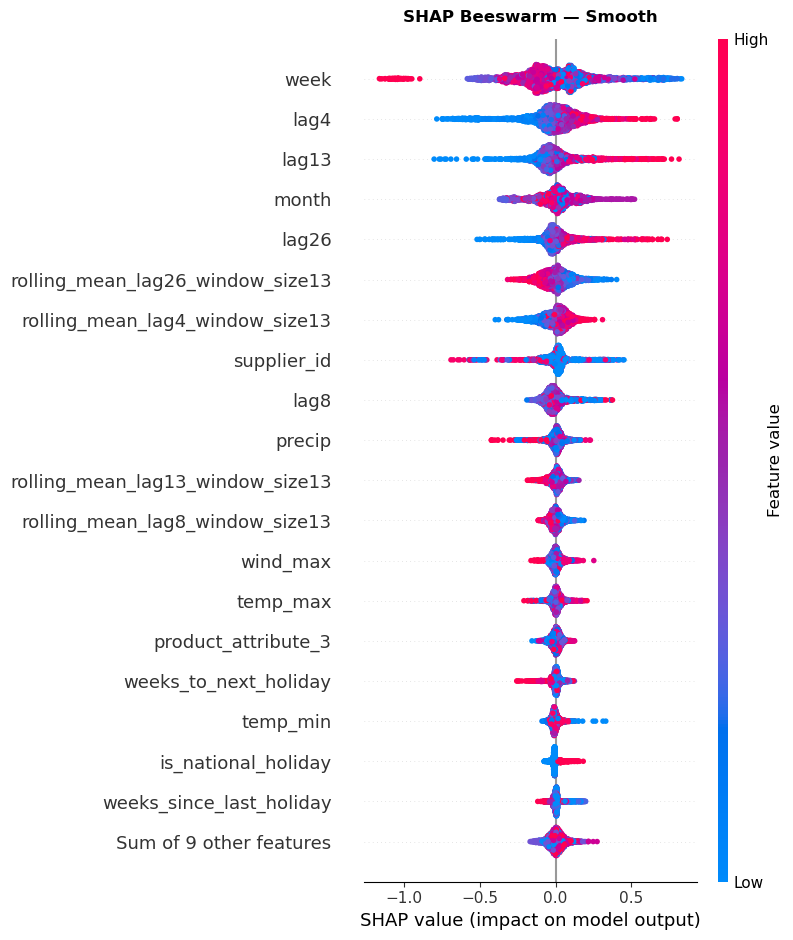

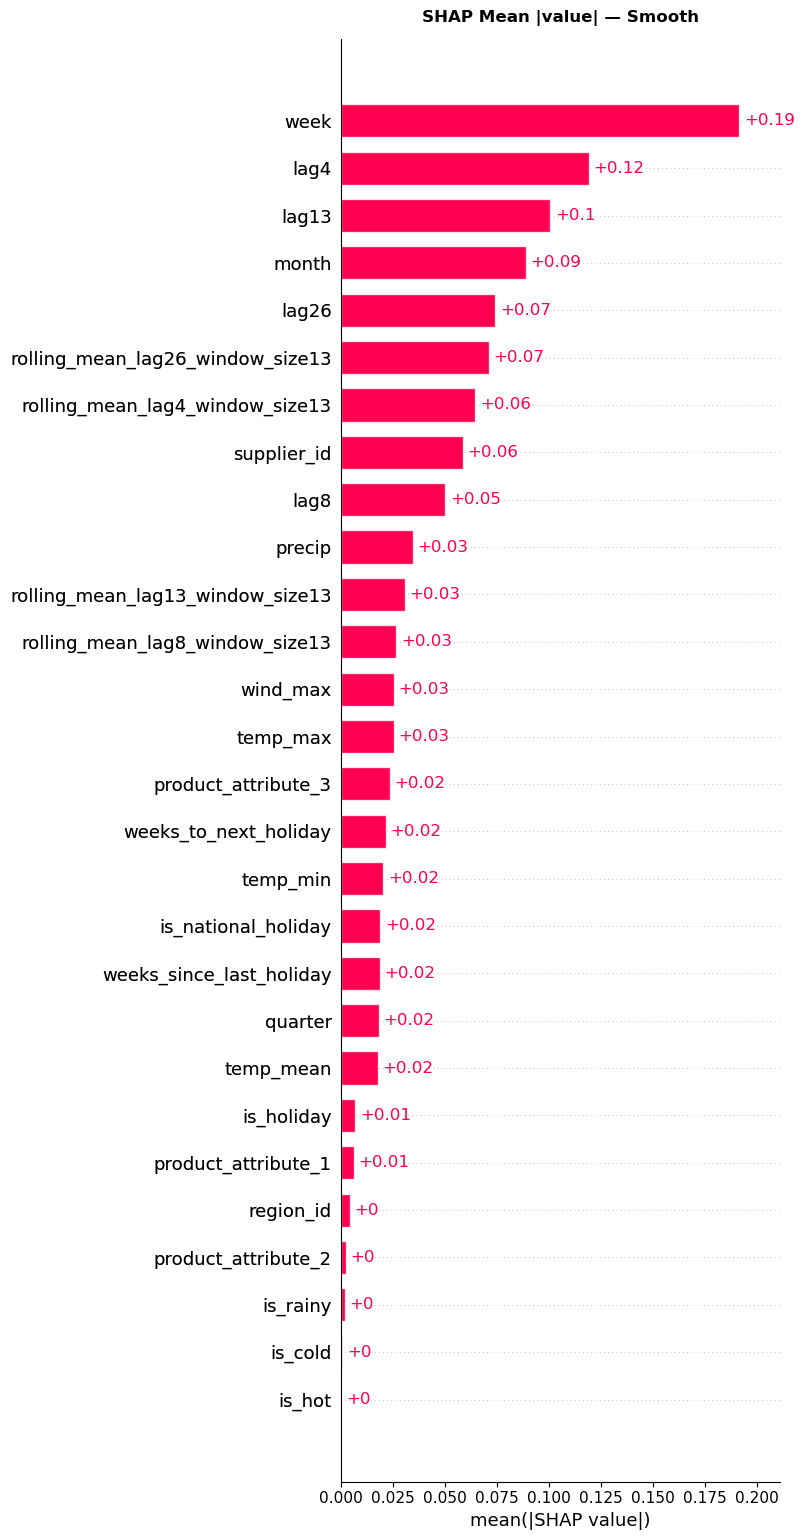


SMOOTH — Top 10 features (mean |SHAP|):
week                                0.191328
lag4                                0.118880
lag13                               0.100575
month                               0.088796
lag26                               0.074105
rolling_mean_lag26_window_size13    0.070921
rolling_mean_lag4_window_size13     0.064392
supplier_id                         0.058298
lag8                                0.050057
precip                              0.034423


In [150]:
import shap
import matplotlib.pyplot as plt
import os

os.makedirs("../../plots", exist_ok=True)

SHAP_SAMPLE = 3_000   # linhas para o explainer (velocidade vs precisão)

for dt in ML_TYPES:
    train, _ = splits[dt]

    # ── Reconstrói o modelo com os melhores params ──────────────────────
    class _FakeTrial:
        def suggest_categorical(self, name, choices): return studies[dt].best_params[name]
        def suggest_int(self, name, *a, **k):         return studies[dt].best_params[name]
        def suggest_float(self, name, *a, **k):       return studies[dt].best_params[name]

    mlf, static_features = build_mlforecast(_FakeTrial(), train)
    mlf.fit(train, static_features=static_features)

    # ── Obtém a matriz de features que o MLForecast usou internamente ───
    prep = mlf.preprocess(train, static_features=static_features)
    model = mlf.models_["LGBMRegressor"]
    feat_cols = model.feature_name_
    X = prep[feat_cols].fillna(0)

    # Amostra para velocidade
    X_sample = X.sample(min(SHAP_SAMPLE, len(X)), random_state=SEED).reset_index(drop=True)

    # ── SHAP TreeExplainer ───────────────────────────────────────────────
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)

    # ── Plot 1: Beeswarm — importância + direção do efeito ──────────────
    fig, ax = plt.subplots(figsize=(9, 7))
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title(f"SHAP Beeswarm — {dt.capitalize()}", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"../../plots/shap_beeswarm_{dt}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Plot 2: Bar — importância média absoluta, paleta azul corporativa ─
    mean_shap = (
        pd.Series(shap_values.values.__abs__().mean(axis=0), index=feat_cols)
        .sort_values(ascending=True)
        .tail(20)
    )
    n = len(mean_shap)

    # Gradient: top feature gets darkest blue, bottom gets lightest
    import numpy as np
    DARK, LIGHT = "#003D60", "#7FA8C2"
    def _hex_to_rgb(h):
        h = h.lstrip("#")
        return tuple(int(h[i:i+2], 16)/255 for i in (0, 2, 4))
    def _lerp(a, b, t):
        return tuple(a[i] + (b[i]-a[i])*t for i in range(3))
    rgb_dark  = _hex_to_rgb(DARK)
    rgb_light = _hex_to_rgb(LIGHT)
    colors = [_lerp(rgb_light, rgb_dark, t) for t in np.linspace(0, 1, n)]

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor("white")
    bars = ax.barh(range(n), mean_shap.values, color=colors, edgecolor="white", linewidth=0.6)

    ax.set_yticks(range(n))
    ax.set_yticklabels(mean_shap.index, fontsize=9)
    ax.set_xlabel("Mean |SHAP value|", fontsize=10)
    ax.set_title(f"Feature Importance — {dt.capitalize()}
Mean |SHAP value| · LightGBM",
                 fontsize=11, fontweight="bold", pad=12, color="#005586")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#005586")
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.grid(axis="x", alpha=0.25, linestyle="--")

    plt.tight_layout()
    plt.savefig(f"../../plots/shap_bar_{dt}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"
{dt.upper()} — Top 10 features (mean |SHAP|):")
    print(mean_shap.iloc[::-1].head(10).to_string())